## Association Rule Mining

Association Rule Mining is an unsupervised learning technique used to discover relationships between items in a dataset. It helps identify patterns showing which items are frequently purchased or occur together.

A popular application is **Market Basket Analysis**. For example, if a customer buys **bread**, what is the probability that they will also buy **butter**? Such insights help businesses improve recommendations, product placement, and sales strategies.

The quality of an association rule is mainly evaluated using three metrics:
- **Support** – How frequently an itemset appears in the dataset.
- **Confidence** – The probability of purchasing item Y when item X is purchased.
- **Lift** – Indicates whether the relationship between X and Y is stronger than a random chance.

In [1]:
#importing required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dataset Description

The dataset contains customer transactions from a supermarket.

- Each row represents a single transaction.
- Each column represents an item purchased by the customer.
- Empty (`NaN`) values indicate that the corresponding item was not purchased.

The objective is to discover hidden purchasing patterns and generate association rules using the Apriori and FP-Growth algorithms.

In [2]:
#loading dataset
df = pd.read_csv('Market_Basket_Optimisation.csv',header = None)
num_records = len(df)
print(num_records)
print(df.info())

7501
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB
None


In [3]:
# Create an empty list to store all transactions
records = []
# Loop through each row (transaction) in the dataset
for i in range(0,df.shape[0]):
    # Convert each row into a list of items
    # Ignore missing (NaN) values because they are not actual items
    records.append([str(df.values[i,j])
                    for j in range(0,df.shape[1])
                    if str(df.values[i,j]) != 'nan'])
    

## Data Preprocessing

This dataset does not require extensive preprocessing because:

- Missing values (`NaN`) simply indicate that an item was not purchased.
- Duplicate transactions are valid and represent actual customer purchases.
- No feature scaling or encoding is required since Association Rule Mining works directly with transactional data.

Therefore, only the transaction records are converted into a list format before applying the algorithms.

In [4]:
# Import Counter to count the frequency of each item
from collections import Counter

# Create an empty list to store all items from every transaction
all_items = []

# Iterate through each transaction (basket)
for basket in records:
    
    # Add all items from the current basket to the list
    all_items.extend(basket)

# Count the frequency of each item and display them in descending order of occurrence
item_counts = Counter(all_items)

top_items = pd.DataFrame(
    item_counts.most_common(10),
    columns=["Item","Frequency"]
)

top_items

,Item,Frequency
0,mineral water,1788
1,eggs,1348
2,spaghetti,1306
3,french fries,1282
4,chocolate,1230
5,green tea,991
6,milk,972
7,ground beef,737
8,frozen vegetables,715
9,pancakes,713


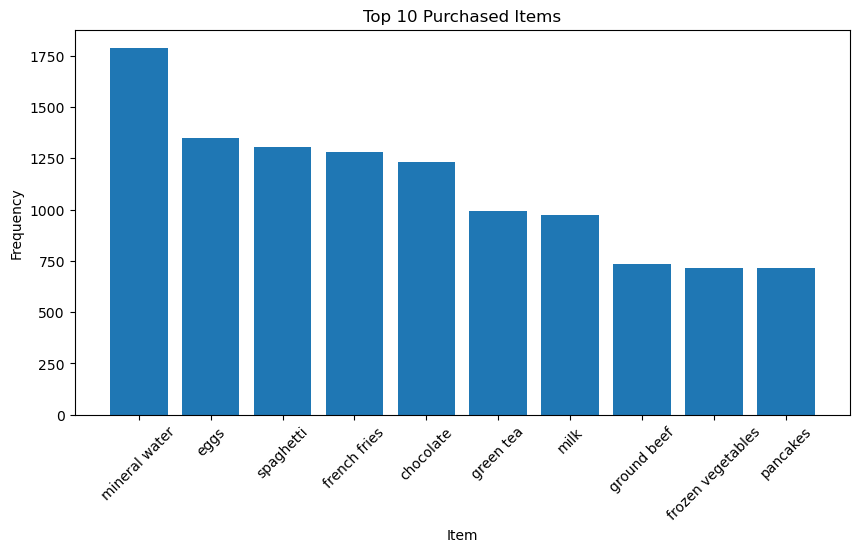

In [5]:
plt.figure(figsize=(10,5))

plt.bar(
    top_items["Item"],
    top_items["Frequency"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Purchased Items")

plt.xlabel("Item")

plt.ylabel("Frequency")

plt.show()

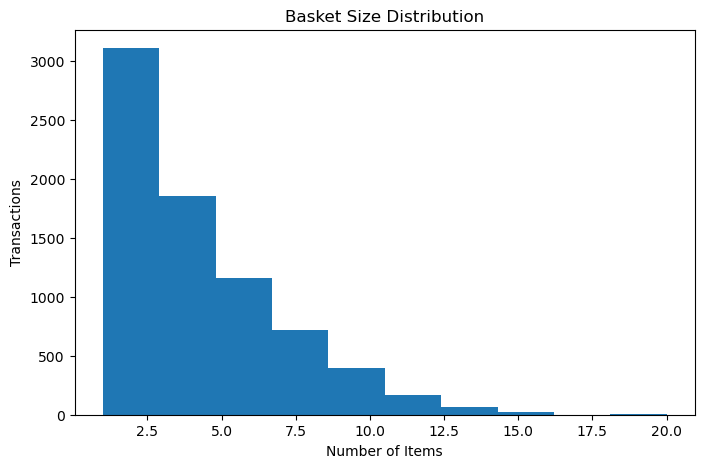

In [6]:
basket_sizes = [len(basket) for basket in records]

plt.figure(figsize=(8,5))

plt.hist(basket_sizes)

plt.xlabel("Number of Items")

plt.ylabel("Transactions")

plt.title("Basket Size Distribution")

plt.show()

## Apriori Algorithm

The **Apriori algorithm** is a popular association rule mining algorithm used to identify frequent itemsets and generate association rules from transactional data.

It works by repeatedly generating candidate itemsets and pruning those that do not satisfy the minimum support threshold. The algorithm follows the **Apriori Principle**:

> **If an itemset is infrequent, then all of its supersets will also be infrequent.**

The strength of the generated association rules is commonly evaluated using **Support**, **Confidence**, and **Lift**.

### Parameters Used

- **min_support = 0.004**
  - Keeps only those itemsets that appear in at least **0.4%** of all transactions.

- **min_confidence = 0.20**
  - Generates rules where the probability of purchasing item **Y** after purchasing **X** is at least **20%**.

- **min_lift = 3**
  - Keeps only strong association rules where the items occur together at least **3 times more often** than expected by chance.

- **min_length = 2**
  - Ensures that each generated rule contains at least **two items** (e.g., X → Y).

In [7]:
# Import the Apriori algorithm
from apyori import apriori
# Generate association rules from the transaction records
rules = apriori(
    records,
    
     # Minimum support required for an itemset to be considered frequent
    min_support=0.004,
    
     # Minimum confidence required for an association rule
    min_confidence=0.20,
    
    # Minimum lift value to ensure a meaningful association
    min_lift=3,
    
    # Minimum number of items in an association rule
    min_length=2
)

rules = list(rules)

The apriori() function returns a generator object, which produces rules one by one to save memory. A generator cannot be indexed or printed completely. By converting it into a list using list(rules), all generated rules are stored in memory, allowing us to iterate over them multiple times, access them using indexing, and analyze or display them easily.

In [8]:
# Display the total number of association rules generated
print(f"Total Association Rules: {len(rules)}")

Total Association Rules: 29


## Converting Apriori Output into a DataFrame

The Apriori algorithm returns the generated association rules as a complex object. To make the results easier to analyze, we extract the important information from each rule and store it in a Pandas DataFrame.

For each rule, we extract:
- **Antecedent** – Items on the left side of the rule (X).
- **Consequent** – Items on the right side of the rule (Y).
- **Support** – Frequency of the itemset in the dataset.
- **Confidence** – Probability of purchasing Y when X is purchased.
- **Lift** – Strength of the association compared to random chance.

Finally, we create a new **Rule** column that combines the antecedent and consequent into a readable format, such as:

**['Milk'] → ['Bread']**

This makes the association rules easier to inspect and interpret.

In [9]:
# Create an empty list to store the extracted association rules
results = []

# Iterate through each rule generated by the Apriori algorithm
for rule in rules:

    # Extract the support value of the current rule
    support = rule.support

    # A single frequent itemset can produce multiple association rules,
    # so iterate through each ordered statistic
    for stat in rule.ordered_statistics:

        # Store the important metrics of each rule in a dictionary
        results.append({

            # Items on the left-hand side of the rule (If part)
            "Antecedent": list(stat.items_base),

            # Items on the right-hand side of the rule (Then part)
            "Consequent": list(stat.items_add),

            # Frequency of the complete itemset in the dataset
            "Support": support,

            # Probability of buying the consequent
            # given that the antecedent is purchased
            "Confidence": stat.confidence,

            # Strength of the association compared to random chance
            "Lift": stat.lift

        })

# Convert the list of dictionaries into a pandas DataFrame
rules_df = pd.DataFrame(results)

# Create a readable representation of each association rule
# Example: ['Milk'] → ['Bread']
# Create a readable representation of each association rule
rules_df["Rule"] = (
    rules_df["Antecedent"].apply(lambda x: ", ".join(sorted(x)))
    + " → " +
    rules_df["Consequent"].apply(lambda x: ", ".join(sorted(x)))
)

# Display the first five association rules
rules_df.head()

,Antecedent,Consequent,Support,Confidence,Lift,Rule
0,[light cream],[chicken],0.004533,0.290598,4.843951,light cream → chicken
1,[mushroom cream sauce],[escalope],0.005733,0.300699,3.790833,mushroom cream sauce → escalope
2,[pasta],[escalope],0.005866,0.372881,4.700812,pasta → escalope
3,[herb & pepper],[ground beef],0.015998,0.323450,3.291994,herb & pepper → ground beef
4,[tomato sauce],[ground beef],0.005333,0.377358,3.840659,tomato sauce → ground beef


## Filtering Strong Association Rules

Not all generated association rules are useful. To identify the most meaningful rules, we apply the following filters:

- **Lift > 3:** Selects rules where the association between items is at least three times stronger than expected by chance.
- **Confidence > 0.5:** Selects rules where the probability of purchasing the consequent given the antecedent is greater than 50%.

These conditions help retain only the strongest and most reliable association rules for further analysis.

In [10]:
rules_df[
    (rules_df["Lift"]>3)
    &
    (rules_df["Confidence"]>0.5)
]

,Antecedent,Consequent,Support,Confidence,Lift,Rule
9,"[ground beef, cooking oil]",[spaghetti],0.004799,0.571429,3.281995,"cooking oil, ground beef → spaghetti"
26,"[shrimp, ground beef]",[spaghetti],0.005999,0.523256,3.005315,"ground beef, shrimp → spaghetti"
30,"[tomatoes, olive oil]",[spaghetti],0.004399,0.611111,3.509912,"olive oil, tomatoes → spaghetti"


In [11]:
# Sort the association rules by Lift in descending order
# Higher Lift indicates a stronger association between items
# A Lift value greater than 1 suggests a positive association.
# The higher the Lift, the more likely the items are purchased together compared to random chance.
rules_df.sort_values(
    by="Lift",
    ascending=False
).head()

,Antecedent,Consequent,Support,Confidence,Lift,Rule
0,[light cream],[chicken],0.004533,0.290598,4.843951,light cream → chicken
2,[pasta],[escalope],0.005866,0.372881,4.700812,pasta → escalope
6,[pasta],[shrimp],0.005066,0.322034,4.506672,pasta → shrimp
32,"[frozen vegetables, ground beef]","[mineral water, spaghetti]",0.004399,0.259843,4.350622,"frozen vegetables, ground beef → mineral water..."
11,"[ground beef, eggs]",[herb & pepper],0.004133,0.206667,4.178455,"eggs, ground beef → herb & pepper"


In [12]:
# Sort the association rules by Confidence in descending order
# Higher Confidence indicates a higher probability that the consequent occurs when the antecedent is present
# A higher confidence value indicates a more reliable association.
rules_df.sort_values(
    by="Confidence",
    ascending=False
).head()

,Antecedent,Consequent,Support,Confidence,Lift,Rule
30,"[tomatoes, olive oil]",[spaghetti],0.004399,0.611111,3.509912,"olive oil, tomatoes → spaghetti"
9,"[ground beef, cooking oil]",[spaghetti],0.004799,0.571429,3.281995,"cooking oil, ground beef → spaghetti"
26,"[shrimp, ground beef]",[spaghetti],0.005999,0.523256,3.005315,"ground beef, shrimp → spaghetti"
15,"[frozen vegetables, olive oil]",[milk],0.004799,0.423529,3.268410,"frozen vegetables, olive oil → milk"
24,"[spaghetti, herb & pepper]",[ground beef],0.006399,0.393443,4.004360,"herb & pepper, spaghetti → ground beef"


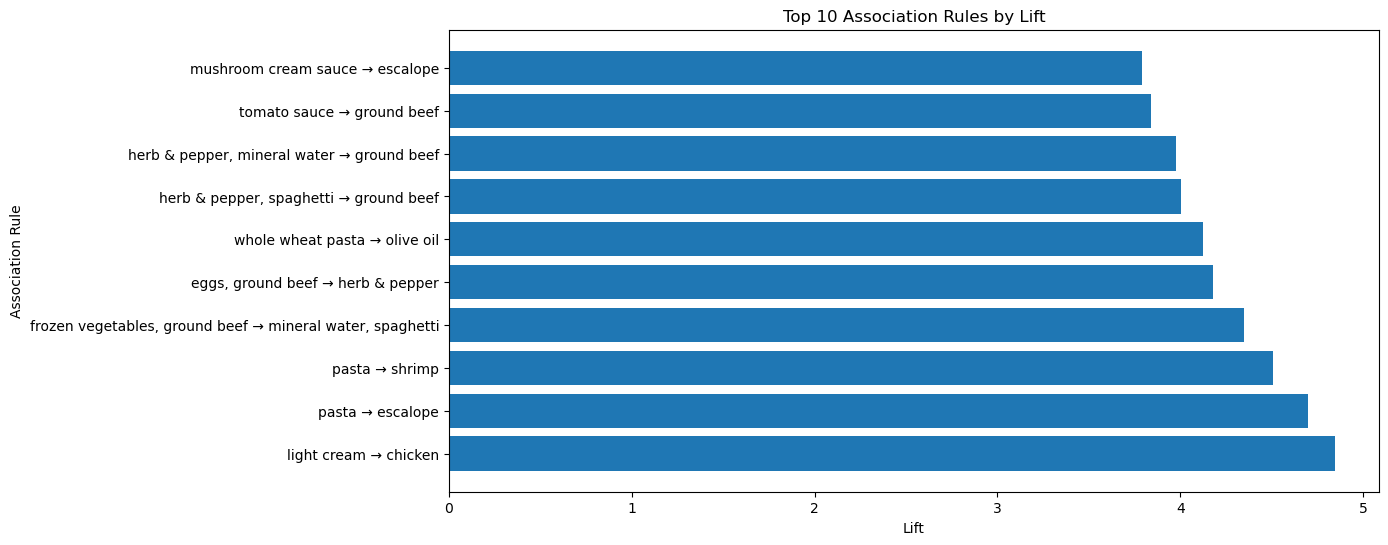

In [13]:
# Select the top 10 association rules with the highest Lift
top10 = rules_df.sort_values("Lift", ascending=False).head(10)

# Create a figure for the horizontal bar chart
plt.figure(figsize=(12,6))

# Plot the Lift value of each association rule
plt.barh(top10["Rule"], top10["Lift"])

# Add labels and title for better readability
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Lift")

# Display the chart
plt.show()

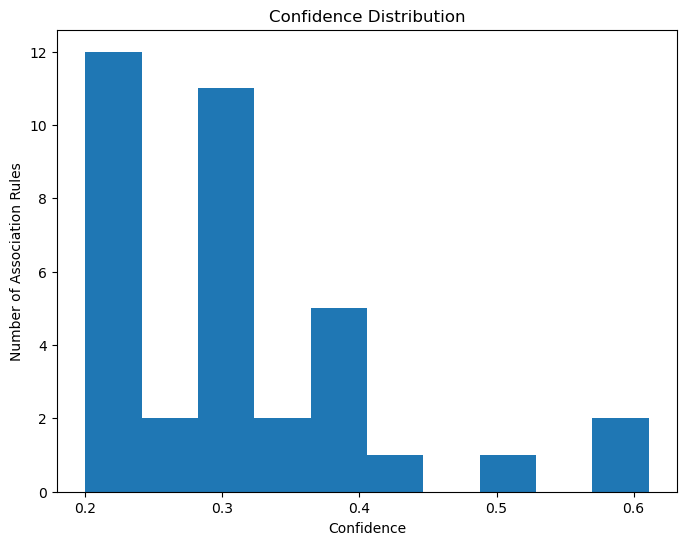

In [30]:
plt.figure(figsize=(8,6))

plt.hist(rules_df["Confidence"], bins=10)

plt.xlabel("Confidence")
plt.ylabel("Number of Association Rules")
plt.title("Confidence Distribution")

plt.show()

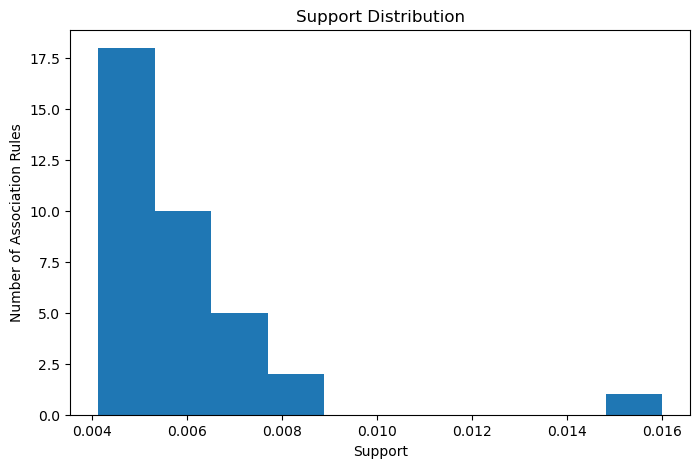

In [15]:
plt.figure(figsize=(8,5))

plt.hist(rules_df["Support"], bins=10)

plt.xlabel("Support")
plt.ylabel("Number of Association Rules")
plt.title("Support Distribution")

plt.show()

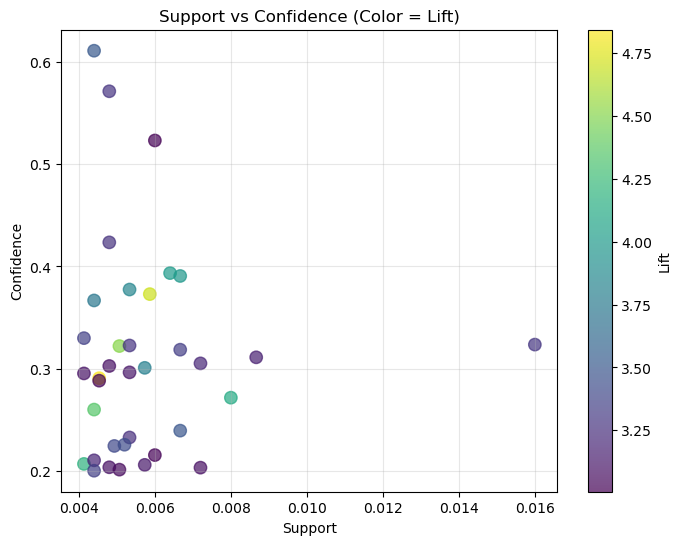

In [16]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    rules_df["Support"],
    rules_df["Confidence"],
    c=rules_df["Lift"],
    s=80,
    alpha=0.7
)

plt.colorbar(scatter, label="Lift")

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Color = Lift)")

plt.grid(alpha=0.3)

plt.show()

| Support                                                          | Confidence                                                                     |
| ---------------------------------------------------------------- | ------------------------------------------------------------------------------ |
| Measures **how often** an itemset appears in the entire dataset. | Measures **how likely** the consequent is to occur when the antecedent occurs. |
| Looks at **all transactions**.                                   | Looks only at transactions containing the antecedent.                          |
| Indicates **frequency**.                                         | Indicates **reliability** of the rule.                                         |


# Advantages of the Apriori Algorithm

- **Simple and Easy to Understand:** Apriori is one of the most intuitive algorithms for discovering association rules and is widely used for learning market basket analysis.

- **Finds Meaningful Patterns:** It identifies frequent itemsets and uncovers relationships between items that occur together in transactions.

- **Pruning Reduces Search Space:** Apriori uses the **Apriori Principle** (if an itemset is infrequent, all of its supersets are also infrequent), which eliminates many unnecessary candidate itemsets.

- **Interpretable Results:** The generated association rules are easy to understand and can be evaluated using metrics such as **Support**, **Confidence**, and **Lift**.

- **Wide Range of Applications:** It is commonly used in retail, e-commerce, healthcare, web usage mining, recommendation systems, and fraud detection.

---

# Limitations of the Apriori Algorithm

- **High Computational Cost:** Apriori generates a large number of candidate itemsets, making it computationally expensive for large datasets.

- **Multiple Database Scans:** The algorithm scans the entire dataset multiple times, increasing execution time.

- **Memory Intensive:** Storing and processing numerous candidate itemsets requires significant memory, especially when the dataset contains many unique items.

- **Slow for Large Datasets:** Performance decreases as the number of transactions and unique items increases.

- **Sensitive to Threshold Selection:** Choosing inappropriate values for minimum support or confidence may either generate too many insignificant rules or miss important associations.

- **Not Suitable for Dense Data:** In datasets where many items frequently occur together, the number of generated candidate itemsets grows rapidly, reducing efficiency.

---

## Conclusion

Apriori is an effective and easy-to-understand algorithm for discovering association rules in transactional data. However, due to its high computational cost and repeated database scans, it is generally preferred for **small to medium-sized datasets**. For larger datasets, algorithms such as **FP-Growth** are often preferred because they are faster and require less memory.

## FP-Growth Algorithm

FP-Growth (Frequent Pattern Growth) is an efficient algorithm used to discover frequent itemsets without generating candidate itemsets.

Unlike Apriori, FP-Growth builds a compact data structure called an **FP-Tree**, which significantly reduces computation time and memory usage, especially for large datasets.

In [17]:
# Import Required Libraries
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

## One-Hot Encoding Transactions

The FP-Growth implementation in **mlxtend** requires the transaction data to be represented as a one-hot encoded DataFrame.

- Each row represents a transaction.
- Each column represents an item.
- A value of **True** indicates that the item is present in the transaction.
- A value of **False** indicates that the item is absent.

In [18]:
# Convert transaction data into one-hot encoded format
te = TransactionEncoder()

te_array = te.fit_transform(records)

df_encoded = pd.DataFrame(
    te_array,
    columns=te.columns_
)

df_encoded.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [19]:
# Generate frequent itemsets using the FP-Growth algorithm
# use_colnames=True displays item names instead of column indices
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=0.004,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.238368,(mineral water)
1,0.132116,(green tea)
2,0.076523,(low fat yogurt)
3,0.071457,(shrimp)
4,0.065858,(olive oil)


In [20]:
# Display the top 10 most frequent itemsets
frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(10)

,support,itemsets
0,0.238368,(mineral water)
20,0.179709,(eggs)
33,0.174110,(spaghetti)
28,0.170911,(french fries)
39,0.163845,(chocolate)
1,0.132116,(green tea)
25,0.129583,(milk)
61,0.098254,(ground beef)
34,0.095321,(frozen vegetables)
53,0.095054,(pancakes)


## Generating Association Rules

After identifying the frequent itemsets, association rules are generated using the **Confidence** metric.

Only rules satisfying the specified confidence threshold are retained for further analysis.

In [21]:
# Generate association rules from the frequent itemsets
# Keep only rules having confidence greater than or equal to 20%
fp_rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

fp_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(green tea),(mineral water),0.132116,0.238368,0.031063,0.235116,0.986357,1.0,-0.000430,0.995748,-0.015688,0.091516,-0.004270,0.182715
1,(green tea),(spaghetti),0.132116,0.174110,0.026530,0.200807,1.153335,1.0,0.003527,1.033405,0.153188,0.094852,0.032325,0.176590
2,(green tea),(french fries),0.132116,0.170911,0.028530,0.215943,1.263488,1.0,0.005950,1.057436,0.240286,0.103934,0.054316,0.191435
3,"(green tea, mineral water)",(spaghetti),0.031063,0.174110,0.008266,0.266094,1.528311,1.0,0.002857,1.125335,0.356765,0.041977,0.111376,0.156784
4,"(green tea, spaghetti)",(mineral water),0.026530,0.238368,0.008266,0.311558,1.307044,1.0,0.001942,1.106312,0.241317,0.032208,0.096096,0.173117


### Observation

The FP-Growth algorithm first discovers frequent itemsets and then generates association rules from them.

Unlike Apriori, FP-Growth does not generate candidate itemsets, making it more scalable for large transactional datasets.

In [22]:
print("Frequent Itemsets:", len(frequent_itemsets))

print("Association Rules:", len(fp_rules))

Frequent Itemsets: 959
Association Rules: 811


In [23]:
# Create Readable Rules
fp_rules["Rule"] = (

    fp_rules["antecedents"].apply(
        lambda x:", ".join(sorted(list(x)))
    )

    + " → " +

    fp_rules["consequents"].apply(
        lambda x:", ".join(sorted(list(x)))
    )

)
fp_rules = fp_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift",
        "Rule"
    ]
]


fp_rules.head()

,antecedents,consequents,support,confidence,lift,Rule
0,(green tea),(mineral water),0.031063,0.235116,0.986357,green tea → mineral water
1,(green tea),(spaghetti),0.026530,0.200807,1.153335,green tea → spaghetti
2,(green tea),(french fries),0.028530,0.215943,1.263488,green tea → french fries
3,"(green tea, mineral water)",(spaghetti),0.008266,0.266094,1.528311,"green tea, mineral water → spaghetti"
4,"(green tea, spaghetti)",(mineral water),0.008266,0.311558,1.307044,"green tea, spaghetti → mineral water"


In [24]:
# Filter Strong Rules
fp_rules[
    (fp_rules["lift"] > 3)
    &
    (fp_rules["confidence"] > 0.5)
]


,antecedents,consequents,support,confidence,lift,Rule
71,"(shrimp, ground beef)",(spaghetti),0.005999,0.523256,3.005315,"ground beef, shrimp → spaghetti"
109,"(tomatoes, olive oil)",(spaghetti),0.004399,0.611111,3.509912,"olive oil, tomatoes → spaghetti"
458,"(ground beef, cooking oil)",(spaghetti),0.004799,0.571429,3.281995,"cooking oil, ground beef → spaghetti"


In [25]:
fp_rules.sort_values(
    by="lift",
    ascending=False
).head()

,antecedents,consequents,support,confidence,lift,Rule
357,(light cream),(chicken),0.004533,0.290598,4.843951,light cream → chicken
573,(pasta),(escalope),0.005866,0.372881,4.700812,pasta → escalope
572,(pasta),(shrimp),0.005066,0.322034,4.506672,pasta → shrimp
416,"(frozen vegetables, ground beef)","(mineral water, spaghetti)",0.004399,0.259843,4.350622,"frozen vegetables, ground beef → mineral water..."
724,"(ground beef, eggs)",(herb & pepper),0.004133,0.206667,4.178455,"eggs, ground beef → herb & pepper"


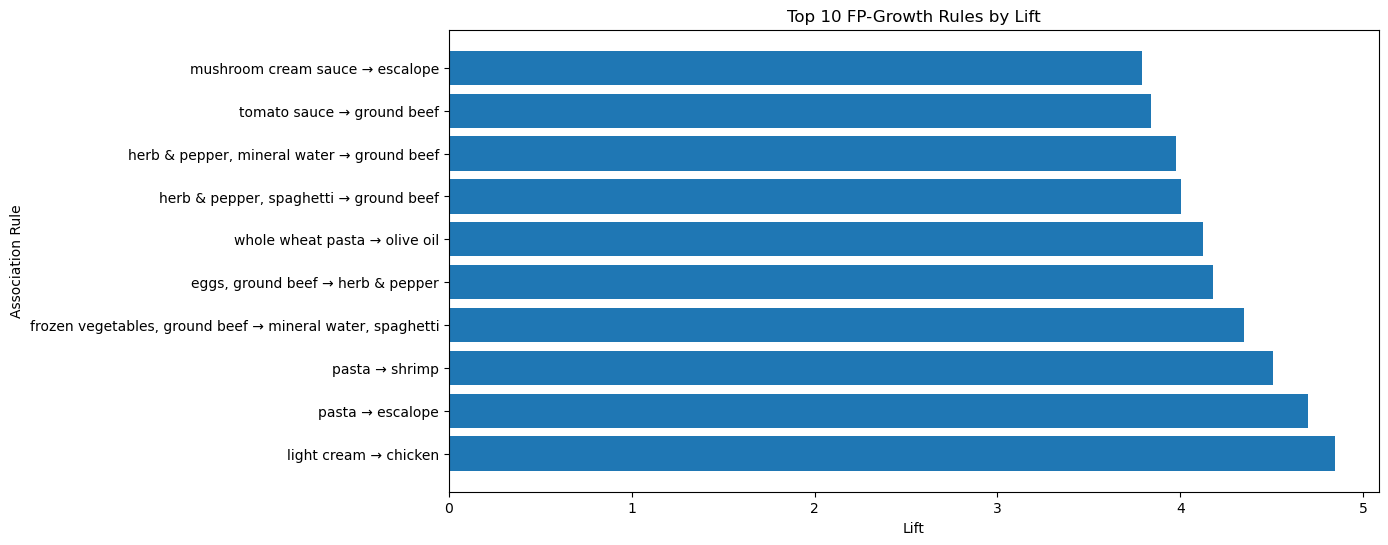

In [26]:
top10 = fp_rules.sort_values(
    "lift",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Rule"],
    top10["lift"]
)

plt.xlabel("Lift")

plt.ylabel("Association Rule")

plt.title("Top 10 FP-Growth Rules by Lift")

plt.show()

In [27]:
fp_rules.sort_values(
    by="confidence",
    ascending=False
).head()

,antecedents,consequents,support,confidence,lift,Rule
351,"(soup, frozen vegetables)",(mineral water),0.005066,0.633333,2.656954,"frozen vegetables, soup → mineral water"
344,"(soup, pancakes)",(mineral water),0.004266,0.627451,2.632276,"pancakes, soup → mineral water"
109,"(tomatoes, olive oil)",(spaghetti),0.004399,0.611111,3.509912,"olive oil, tomatoes → spaghetti"
317,"(whole wheat rice, pancakes)",(mineral water),0.004133,0.596154,2.500979,"pancakes, whole wheat rice → mineral water"
460,"(cooking oil, pancakes)",(mineral water),0.004666,0.593220,2.488672,"cooking oil, pancakes → mineral water"


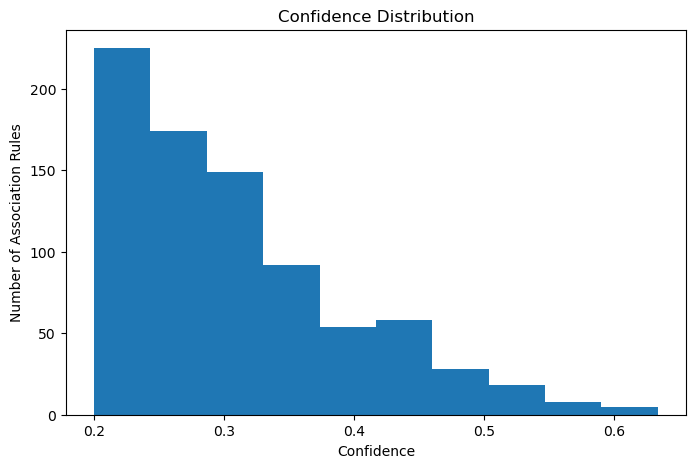

In [28]:
plt.figure(figsize=(8,5))

plt.hist(fp_rules["confidence"])

plt.xlabel("Confidence")
plt.ylabel("Number of Association Rules")
plt.title("Confidence Distribution")

plt.show()

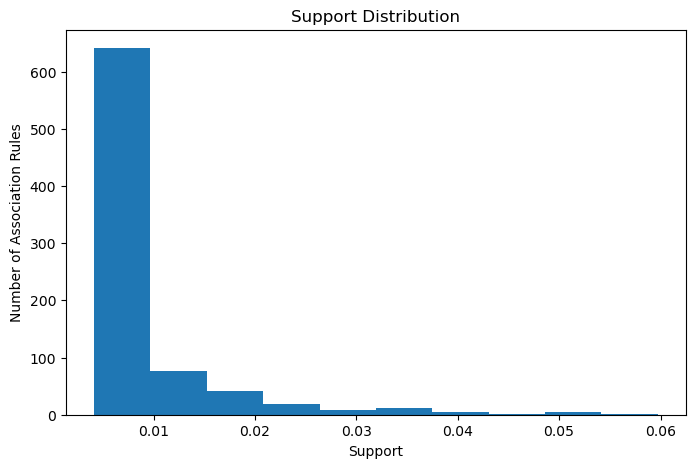

In [29]:
plt.figure(figsize=(8,5))

plt.hist(fp_rules["support"])

plt.xlabel("Support")
plt.ylabel("Number of Association Rules")
plt.title("Support Distribution")

plt.show()

## Business Insights

- Mineral Water is one of the most frequently purchased products.
- Customers purchasing certain product combinations are more likely to purchase additional related items.
- These association rules can improve product recommendations.
- Frequently associated products can be placed closer together to encourage cross-selling.
- Retailers can use these insights for promotions, bundle offers, and store layout optimization.

## Real-World Applications

Association Rule Mining is widely used in:

- Market Basket Analysis
- Recommendation Systems
- Cross-selling and Upselling
- Product Bundling
- Store Layout Optimization
- E-commerce Product Recommendations
- Customer Purchase Behavior Analysis

## Conclusion

In this project, Association Rule Mining was implemented using both the Apriori and FP-Growth algorithms.

Both algorithms successfully identified meaningful relationships between products purchased together.

While Apriori is simple and easy to understand, FP-Growth is more suitable for large datasets because it avoids candidate generation and efficiently mines frequent patterns using an FP-Tree.

The generated association rules can be used to improve recommendation systems, cross-selling strategies, and business decision-making.